In [4]:
import numpy as np
import pandas as pd 

In [5]:
df = pd.read_csv(r"C:\AHAMMED\AI-Powered E-commerce Customer Intelligence System\Dataset\data.csv", encoding="latin1")

EDA  Exploritary Data Analyisis

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [8]:
df.shape

(541909, 8)

In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [11]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [12]:
df.describe(include="O")

C:\Users\ahamm\AppData\Local\Temp\ipykernel_33868\504318277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(5268)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.dropna(subset=['CustomerID'], inplace=True)

In [17]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [18]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

##Feature Engineering

In [19]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [20]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [21]:
def engineer_features(dataframe):
    """Generates time-series and financial features for transaction data."""
    df = dataframe.copy()
    
    # Financial feature
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
    
    # Temporal features
    df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
    df['Month'] = df['InvoiceDate'].dt.month
    df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
    df['Hour'] = df['InvoiceDate'].dt.hour
    
    return df

df_engineered = engineer_features(df)

In [22]:
import datetime as dt

def calculate_rfm(df):
    """Aggregates transactional data into a Customer RFM matrix."""
    
    # Establish the snapshot date (1 day after the last transaction in the dataset)
    snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
    
    # Aggregate to customer level
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days, 
        'InvoiceNo': 'nunique',                                  
        'TotalAmount': 'sum'                                     
    }).reset_index()
    
    # Rename columns for standard RFM nomenclature
    rfm.rename(columns={
        'InvoiceDate': 'Recency',
        'InvoiceNo': 'Frequency',
        'TotalAmount': 'Monetary'
    }, inplace=True)
    
    return rfm

rfm_matrix = calculate_rfm(df_engineered)

In [25]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Handle zeroes for log transformation by adding 1
rfm_log = rfm_matrix[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log = np.log(rfm_log + 1)

# 2. Standardize the scales
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert back to dataframe for easier handling
import pandas as pd
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_matrix.index, columns=rfm_log.columns)

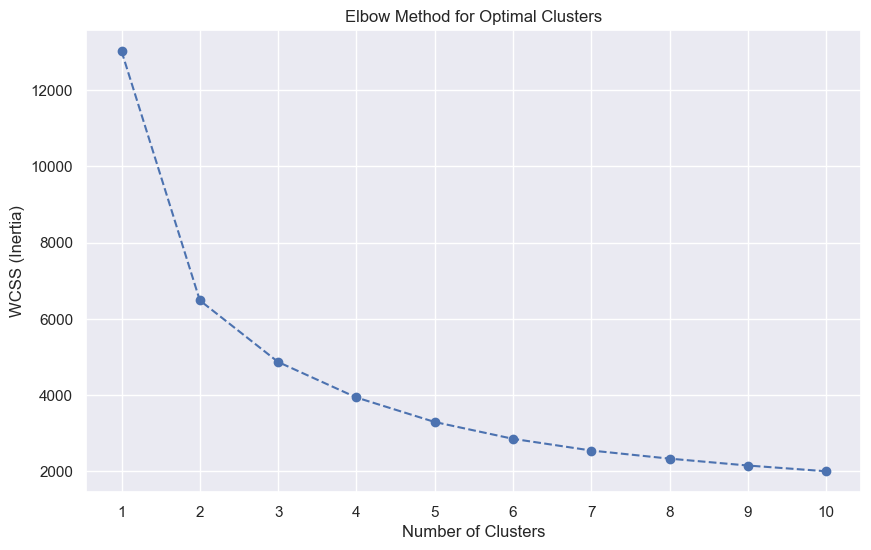

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual theme
sns.set_theme(style="darkgrid")

wcss = []
k_range = range(1, 11)

# Calculate WCSS for 1 to 10 clusters
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.show()

In [29]:
# Initialize and fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# Assign the cluster labels to the original (unscaled) RFM dataframe
rfm_matrix['Cluster'] = kmeans.labels_

# Display the size of each cluster
print(rfm_matrix['Cluster'].value_counts())

Cluster
1    1622
3    1166
2     837
0     713
Name: count, dtype: int64


In [30]:
# Calculate the average RFM values and the customer count per cluster
cluster_summary = rfm_matrix.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)

# Rename the ID column to Count for clarity
cluster_summary.rename(columns={'CustomerID': 'Count'}, inplace=True)

print(cluster_summary)

         Recency  Frequency  Monetary  Count
Cluster                                     
0          12.17      13.75   8088.02    713
1         181.51       1.32    341.00   1622
2          17.70       2.19    557.32    837
3          71.64       4.08   1801.78   1166


In [31]:
# Map cluster numbers to business personas
persona_map = {
    0: 'Champions',
    1: 'Lost/Churned',
    2: 'New/Promising',
    3: 'Loyal/Regulars'
}

# Create the new column
rfm_matrix['Persona'] = rfm_matrix['Cluster'].map(persona_map)

# Verify the final dataset structure
print(rfm_matrix[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Persona']].head())

  CustomerID  Recency  Frequency  Monetary         Persona
0      12346      326          1  77183.60  Loyal/Regulars
1      12347        2          7   4310.00       Champions
2      12348       75          4   1797.24  Loyal/Regulars
3      12349       19          1   1757.55   New/Promising
4      12350      310          1    334.40    Lost/Churned


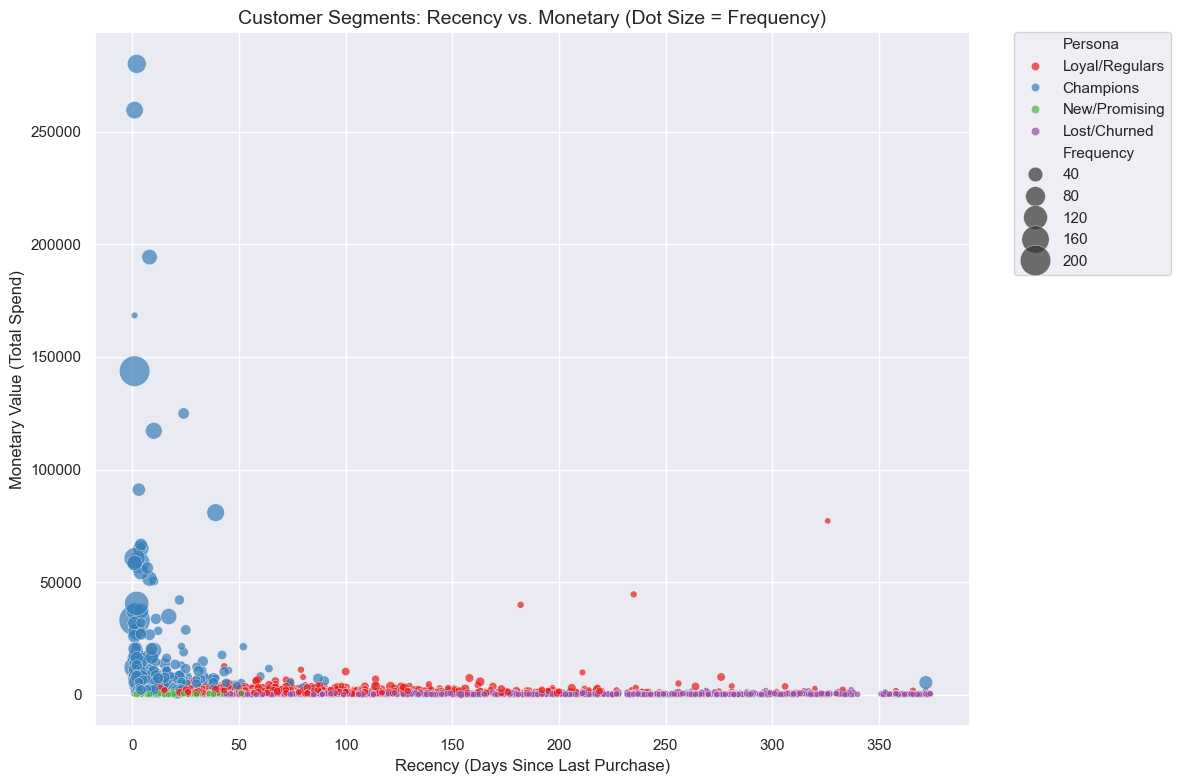

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual theme to a clean, high-contrast grid
sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 8))

# Build the scatter plot
sns.scatterplot(
    data=rfm_matrix, 
    x='Recency', 
    y='Monetary', 
    hue='Persona', 
    size='Frequency',
    sizes=(20, 500), # Adjust dot size constraints
    alpha=0.7,
    palette='Set1' # Use a distinct color palette
)

# Set labels and title
plt.title('Customer Segments: Recency vs. Monetary (Dot Size = Frequency)', fontsize=14)
plt.xlabel('Recency (Days Since Last Purchase)', fontsize=12)
plt.ylabel('Monetary Value (Total Spend)', fontsize=12)

# Move the legend outside the plot for readability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

plt.show()